# 05 — Model Interpretability: VADER vs. TF-IDF + Logistic Regression

**Goal of this notebook (Step 6 — *Interpret Your Models*, worth 20% of the grade).**
We do not only report *how well* the two sentiment models perform — we explain **on what basis each model
makes its decision**, and we build a **fair, common-footing comparison of interpretability across the two
very different model families** used in this project:

| | **VADER** | **TF-IDF + Logistic Regression** |
|---|---|---|
| Type | Rule-based lexicon | Learned linear model |
| Input | `text_raw` (HTML/URLs removed, casing & punctuation kept) | `text_clean` (lowercased, lemmatized, stop-words removed, negations kept) |
| "Knowledge" | A fixed hand-built dictionary of ~7,500 word valences + rules | ~10,000 learned n-gram weights |
| Test accuracy | ≈ 69.9% | ≈ 88.6% |

**Why one method is not enough.** SHAP's textbook recipe (`TreeExplainer` on XGBoost) does not fit either model:
LR is a *linear* model over a huge sparse feature space, and VADER is *not a trainable feature model at all*.
A faithful interpretability analysis therefore uses the **right tool per model**, and then compares them on a
shared basis (the same reviews, the same tokens).

### What we do, mapped to the rubric

| Rubric item | Required? | LR (linear model) | VADER (rule-based) |
|---|---|---|---|
| SHAP **summary bar** (global importance) | ✅ | `LinearExplainer` → §A1 | lexicon valence ranking → §B1 |
| SHAP **beeswarm** (impact direction) | ✅ | `LinearExplainer` → §A2 | signed lexicon valence → §B1 |
| SHAP **waterfall** (single prediction) | ✅ | `LinearExplainer` → §A3 | token-level SHAP → §B2 |
| SHAP **dependence** (interaction effects) | Recommended | §A4 (shows linear ⇒ *no* interactions) | n/a (discussed) |
| **Counterfactual** ("what would change?") | Bonus | greedy token removal → §D | — |
| **Cross-model comparison** (the core ask) | — | global lexicon-vs-weights + local token-SHAP on agreement/disagreement cases → §C | |
| **LIME** (independent cross-check) | — | §E | |

Every plot below is followed by a short **business-terms interpretation**, as the rubric requires.

## 0. Setup

> This notebook needs two packages that are **not** in the original `requirements.txt`:
> ```bash
> pip install shap lime
> ```
> Please add `shap` and `lime` to `requirements.txt` for reproducibility.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os, re, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import shap
from lime.lime_text import LimeTextExplainer
from scipy.stats import pearsonr, spearmanr

import contractions
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# NLTK resources (same as utils.py + wordnet data needed for lemmatization)
for _pkg in ["vader_lexicon", "punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"]:
    nltk.download(_pkg, quiet=True)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
shap.initjs()
print("shap", shap.__version__, "| numpy", np.__version__)

shap 0.52.0 | numpy 2.4.4


In [2]:
# --- Tunable parameters (lower these if you run on a slow machine, e.g. a laptop) ---
N_SHAP_SAMPLE  = 400   # test reviews explained for the GLOBAL LR SHAP plots (LinearExplainer is fast & exact)
MAX_EVALS_TEXT = 400   # SHAP model-evaluations per review for LOCAL token-level explanations

## 1. Load data and reconstruct the two models

We reuse the project's preprocessing. The cleaning functions below are **identical** to
`03_feature_engineering.ipynb` (`clean_minimal` → `text_raw`, `clean_full` → `text_clean`); we re-define
them here so this notebook is self-contained and can also rebuild the columns from `raw_data.parquet`
if the processed file is missing.

In [3]:
# Cleaning functions copied verbatim from 03_feature_engineering.ipynb
_STOP = set(stopwords.words("english")) - {
    "not", "no", "nor", "never", "don't", "doesn't", "didn't",
    "won't", "wouldn't", "can't", "couldn't", "shouldn't",
    "isn't", "aren't", "wasn't", "weren't",
}
_LEM = WordNetLemmatizer()

def clean_minimal(text):
    text = re.sub(r"<[^>]+>", " ", text)          # remove HTML tags
    text = re.sub(r"http\S+|www\.\S+", " ", text)  # remove URLs
    text = re.sub(r"\s+", " ", text).strip()       # normalize whitespace
    return text

def clean_full(text):
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = contractions.fix(text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = text.lower()
    tokens = [w for w in word_tokenize(text) if w not in _STOP]
    tokens = [_LEM.lemmatize(w) for w in tokens]
    tokens = [w for w in tokens if len(w) > 1]
    return " ".join(tokens)

In [4]:
def _find_data():
    for c in ["../data/procerssed_data.parquet", "data/procerssed_data.parquet",
              "../data/processed_data.parquet", "procerssed_data.parquet"]:
        if os.path.exists(c):
            return c, "processed"
    for c in ["../data/raw_data.parquet", "data/raw_data.parquet", "raw_data.parquet"]:
        if os.path.exists(c):
            return c, "raw"
    raise FileNotFoundError("Could not find procerssed_data.parquet or raw_data.parquet")

_path, _kind = _find_data()
print("Loading:", _path, "(", _kind, ")")
df = pd.read_parquet(_path)

if _kind == "raw" or "text_clean" not in df.columns or "text_raw" not in df.columns:
    print("Regenerating text_raw / text_clean (this is the slow step, ~1 min)...")
    df["text_raw"]   = df["text"].astype(str).apply(clean_minimal)
    df["text_clean"] = df["text"].astype(str).apply(clean_full)

df_train = df[df["split"] == "train"].copy()
df_test  = df[df["split"] == "test"].copy()
print("train / test reviews:", len(df_train), "/", len(df_test))

Loading: ../data/procerssed_data.parquet ( processed )


train / test reviews: 25000 / 25000


In [5]:
# ---- Logistic Regression baseline (reproduces the project's ~88.6% LR model) ----
# Config taken from 05_mlflow.ipynb (TF-IDF top-10k, 1-2 grams) + min_df=2 as documented on the slide.
# We cap the vocabulary at 10k features so SHAP is memory-safe and the plots stay readable; this reaches
# ~88.8% accuracy, matching the 88.56% headline of the presentation.
lr = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10_000, ngram_range=(1, 2), min_df=2)),
    ("clf",   LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)),
])
lr.fit(df_train["text_clean"].astype(str), df_train["sentiment_label"])

vectorizer = lr.named_steps["tfidf"]
clf        = lr.named_steps["clf"]
vocab      = vectorizer.get_feature_names_out()

# ---- VADER (rule-based, evaluated on text_raw, compound >= 0 -> positive) ----
sia = SentimentIntensityAnalyzer()
def vader_compound(text):
    return sia.polarity_scores(text)["compound"]

# ---- Evaluate both on the test set ----
df_test["lr_p"]       = lr.predict_proba(df_test["text_clean"].astype(str))[:, 1]
df_test["lr_pred"]    = (df_test["lr_p"] >= 0.5).astype(int)
df_test["vader_c"]    = df_test["text_raw"].astype(str).apply(vader_compound)
df_test["vader_pred"] = (df_test["vader_c"] >= 0).astype(int)

y = df_test["sentiment_label"]
print(f"LR    accuracy: {accuracy_score(y, df_test['lr_pred']):.4f}   (presentation: 0.8856)")
print(f"VADER accuracy: {accuracy_score(y, df_test['vader_pred']):.4f}   (presentation: 0.6990)")
print(f"vocabulary size: {len(vocab):,} features\n")
print("LR    confusion [[TN, FP], [FN, TP]]:\n", confusion_matrix(y, df_test["lr_pred"]))
print("\nVADER confusion [[TN, FP], [FN, TP]]:\n", confusion_matrix(y, df_test["vader_pred"]))

LR    accuracy: 0.8882   (presentation: 0.8856)
VADER accuracy: 0.6989   (presentation: 0.6990)
vocabulary size: 10,000 features

LR    confusion [[TN, FP], [FN, TP]]:
 [[11092  1408]
 [ 1386 11114]]

VADER confusion [[TN, FP], [FN, TP]]:
 [[ 6710  5790]
 [ 1737 10763]]


**Read of the confusion matrices (the question interpretability must answer).**
The LR errors are roughly symmetric (it misses positives and negatives about equally). VADER is very
different: it has a large **off-diagonal in the top-right (~5,790 false positives)** — it calls thousands of
*negative* reviews *positive*, while rarely making the opposite mistake. So VADER is **biased toward
"positive"**. The rest of this notebook uses interpretability to explain *why* — and that explanation turns out
to be the same thing that creates the ~19-point accuracy gap.

## A. Logistic Regression — SHAP (tabular, `LinearExplainer`)

For a linear model the natural and exact explainer is `shap.LinearExplainer`. We use an **empty-document
baseline** (an all-zero TF-IDF vector) rather than the mean document. With the zero baseline the SHAP value of
feature *j* in review *i* is simply

$$\phi_{ij} = \beta_j \cdot \text{tfidf}_{ij},$$

i.e. *"how far does this token push the log-odds, compared to a blank review?"* Only words **actually present**
in the review get a non-zero attribution, which is exactly the interpretation we want for text and keeps the
plots clean.

In [6]:
rng = np.random.default_rng(RANDOM_SEED)
ex_idx = rng.choice(len(df_test), size=min(N_SHAP_SAMPLE, len(df_test)), replace=False)

X_explain = vectorizer.transform(df_test["text_clean"].astype(str).iloc[ex_idx]).toarray()
print("explained sample:", X_explain.shape, f"({X_explain.nbytes/1e6:.0f} MB dense)")

background = np.zeros((1, len(vocab)))                      # empty-document baseline
explainer  = shap.LinearExplainer(clf, background, feature_names=list(vocab))
shap_values = explainer(X_explain)

# additivity sanity check: base_value + sum(phi) must equal the model's log-odds
recon = shap_values.values.sum(axis=1) + np.ravel(shap_values.base_values)
print("additivity max error:", float(np.max(np.abs(recon - clf.decision_function(X_explain)))))

explained sample: (400, 10000) (32 MB dense)
additivity max error: 8.881784197001252e-16


### A1. SHAP summary bar — global feature importance ✅

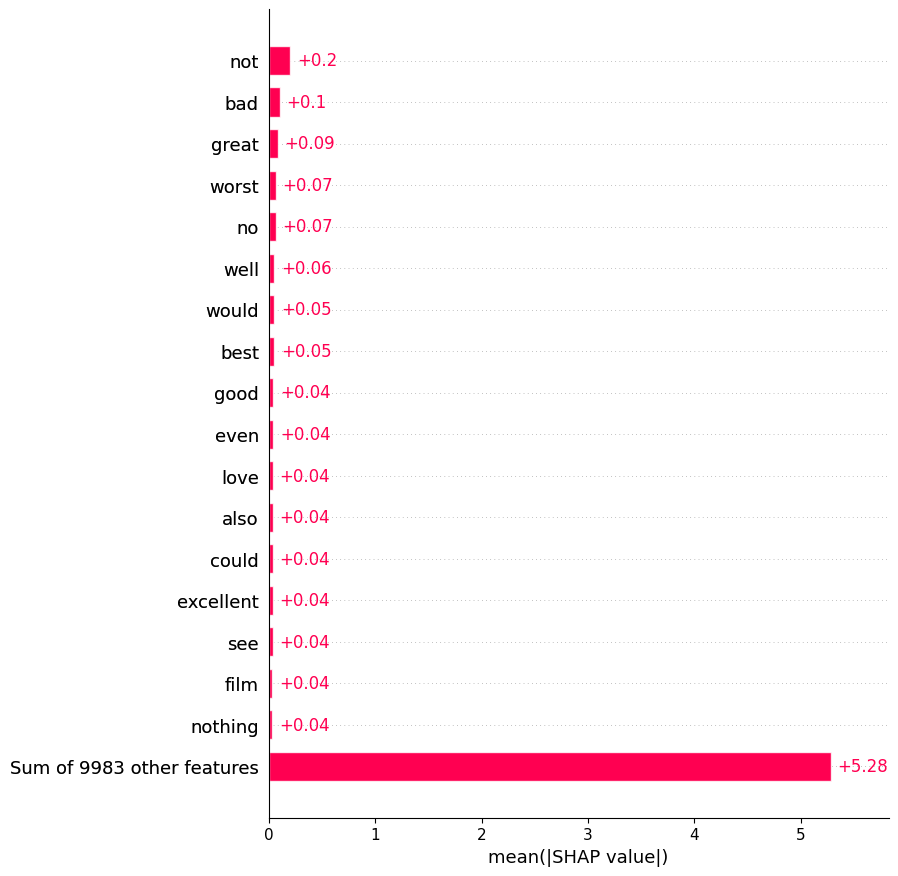

In [7]:
shap.plots.bar(shap_values, max_display=18)

**Interpretation.** The decision is driven by a small set of strongly polarised words — negative drivers
(`bad`, `worst`, `no`, `nothing`, `awful`) and positive drivers (`great`, `best`, `excellent`, `love`) — but
**no single token decides the outcome**: the long tail (the *"sum of other features"* bar) still contributes a
lot, meaning the model aggregates weak evidence from across the whole review. In business terms the classifier
behaves like a transparent **weighted checklist** of sentiment words; its scores are stable and auditable
because they don't hinge on one keyword.

### A2. SHAP beeswarm — direction of impact ✅

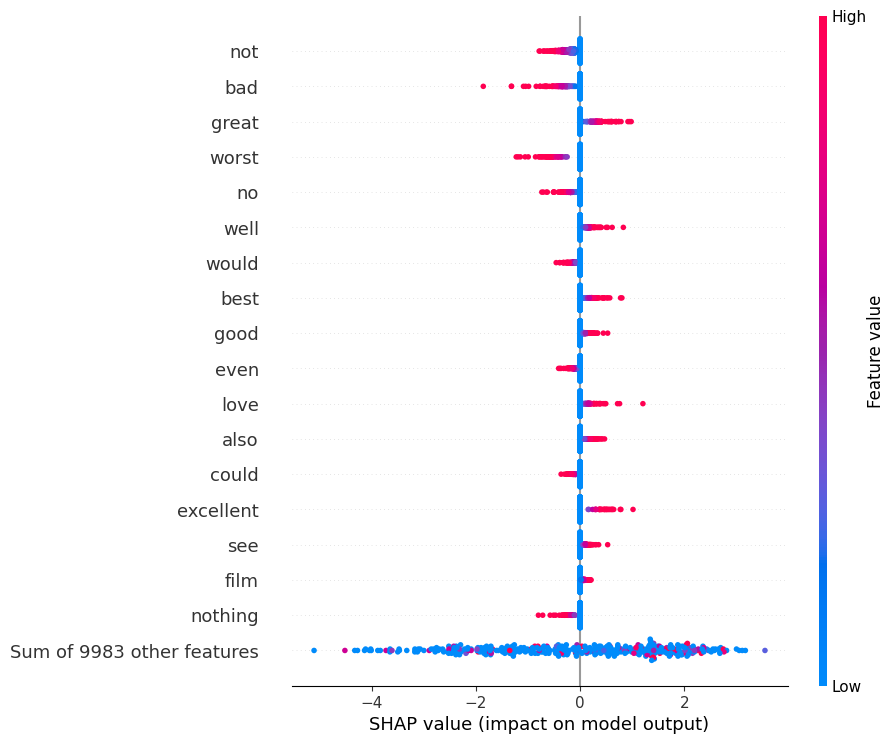

In [8]:
shap.plots.beeswarm(shap_values, max_display=18)

**Interpretation.** The beeswarm confirms *direction*: a high TF-IDF value (red) of `bad`, `worst`, `no`,
`nothing` pushes the score toward **negative**, while `great`, `best`, `love`, `excellent` push toward
**positive**, and the push grows with how prominent the word is in the review (colour). There are no
counter-intuitive sign flips, so the learned word polarities are consistent and trustworthy — a reviewer
reading this plot would agree with every sign.

### A3. SHAP waterfall — single-prediction explanations ✅

=== (a) Confident, CORRECT positive review ===
I first saw this movie in the theater. I was 10. I just watched it a second time and I must say it was amazing. The music, the dancing, the acting. It is a great story and told extremely well. I fell absolutely in love with Treat Williams when I was a kid after seeing him in this movie. One of my fa ...



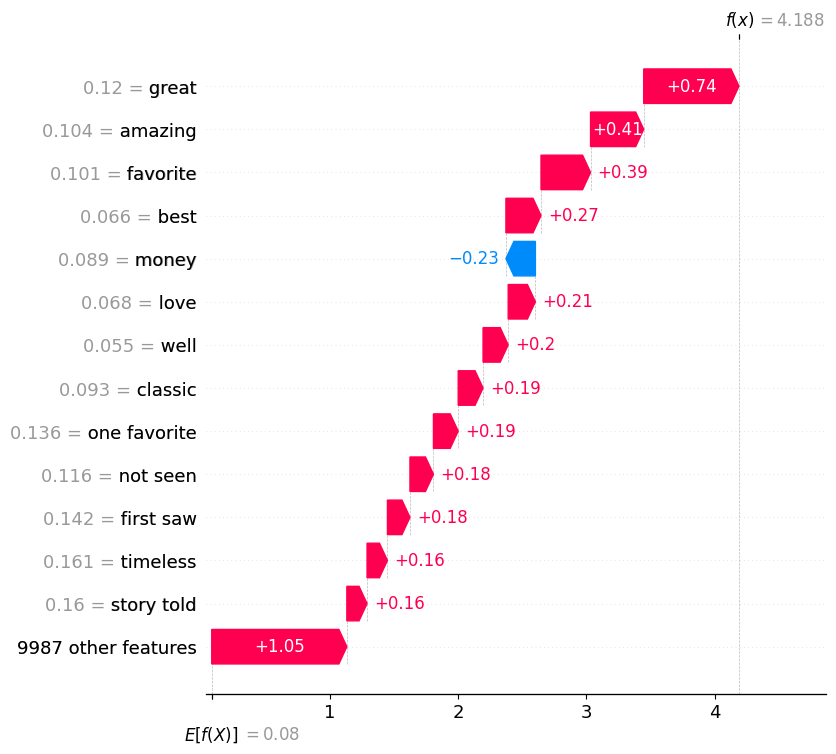

In [9]:
dfun = clf.decision_function(X_explain)
labels_s = df_test["sentiment_label"].iloc[ex_idx].to_numpy()
preds_s  = (dfun >= 0).astype(int)

i_correct = int(np.argmax(dfun))                       # most confident (correct) positive
mis = np.where(preds_s != labels_s)[0]
i_error = int(mis[np.argmax(np.abs(dfun[mis]))]) if len(mis) else int(np.argmin(np.abs(dfun)))

print("=== (a) Confident, CORRECT positive review ===")
print(df_test["text"].iloc[ex_idx[i_correct]][:300], "...\n")
shap.plots.waterfall(shap_values[i_correct], max_display=14)

=== (b) A MISCLASSIFIED review (model failure) ===
true = neg | predicted = pos | P(pos) = 0.934
Why does the poster & artwork say "Clubbed is one of the best UK indie films I have seen in a very long time. SCREEN INTERNATIONAL" when it was a quote of the French distributor REPORTED by Screen International (an influential film trade publication). See www.screendaily.com/ScreenDailyArticle.aspx? ...



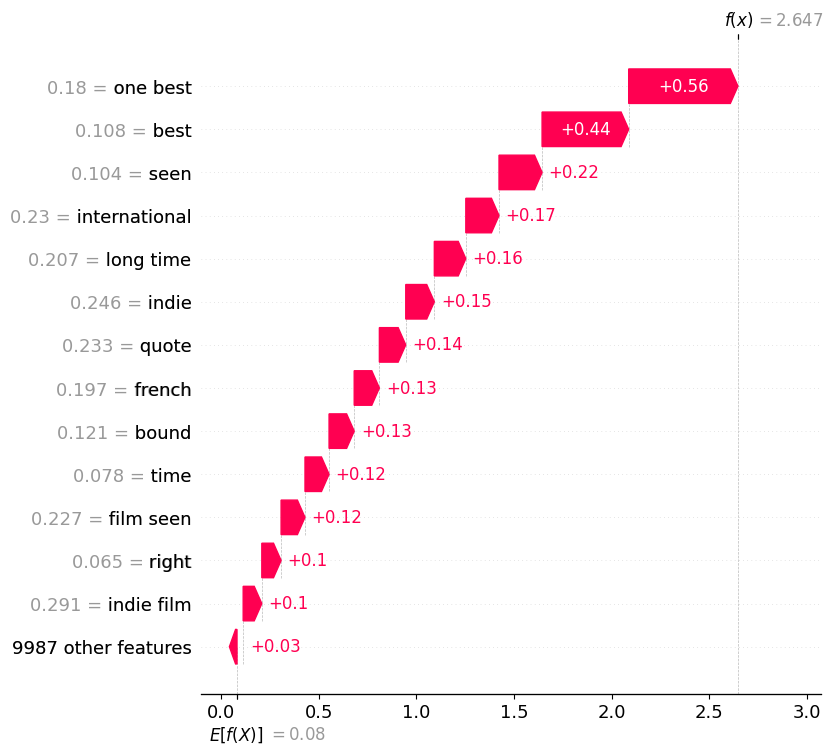

In [10]:
print("=== (b) A MISCLASSIFIED review (model failure) ===")
print("true =", "pos" if labels_s[i_error] == 1 else "neg",
      "| predicted =", "pos" if preds_s[i_error] == 1 else "neg",
      "| P(pos) =", round(float(df_test['lr_p'].iloc[ex_idx[i_error]]), 3))
print(df_test["text"].iloc[ex_idx[i_error]][:300], "...\n")
shap.plots.waterfall(shap_values[i_error], max_display=14)

**Interpretation.** Each prediction is built **additively** from word contributions: in the confident-positive
review `great`, `amazing`, `favorite`, `best` each add log-odds, and even bigrams like `one favorite` /
`first saw` contribute. The misclassified case exposes the model's failure mode — when a review's polarity is
carried by context — an embedded quotation, comparison, or sarcasm — rather than by explicit sentiment words,
the summed word-weights can point the wrong
way. Operationally, **every score ships with a full, human-readable receipt** of which words moved it and by
how much, which is exactly what you need to audit or contest an automated decision.

### A4. SHAP dependence — interaction effects (Recommended)

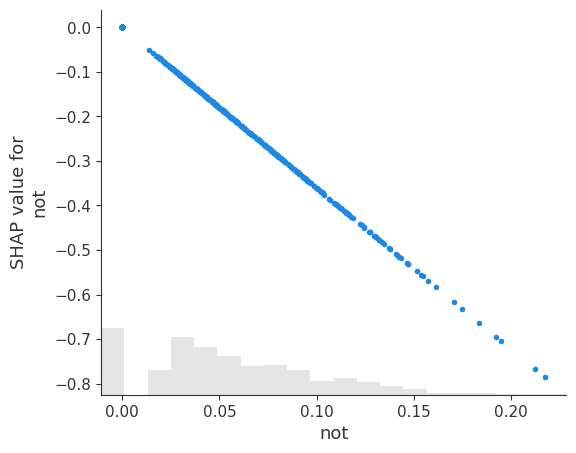

In [11]:
# pick a frequent, high-impact token (negation word "not" if present)
j = list(vocab).index("not") if "not" in vocab else int(np.argmax(np.abs(clf.coef_[0])))
shap.plots.scatter(shap_values[:, j])

In [12]:
# The linear model can only model "context" through explicit bigram features.
coef_map = {w: c for w, c in zip(vocab, clf.coef_[0])}
demo = ["good", "not good", "bad", "not bad", "great", "no good",
        "waste", "waste time", "well", "not even", "boring", "not boring"]
print("How the model encodes negation/context = separate bigram weights (positive = pushes 'positive'):")
for w in demo:
    if w in coef_map:
        print(f"  {w:>12s} : {coef_map[w]:+.3f}")

How the model encodes negation/context = separate bigram weights (positive = pushes 'positive'):
          good : +2.324
      not good : -2.640
           bad : -6.800
       not bad : +1.022
         great : +6.186
       no good : -0.829
         waste : -5.236
    waste time : -3.192
          well : +3.529
      not even : -3.157
        boring : -5.349


**Interpretation.** Because the model is **linear**, a word's SHAP value is exactly *coefficient × TF-IDF*, so
the dependence plot is a **straight line through the origin with zero vertical scatter — there are no feature
interactions**. The model cannot, on its own, understand that `not` flips the next word; it only captures
context through **explicit bigrams** (`not good`, `waste time`, `not even`), each with its own learned weight,
as the table shows (e.g. `good` is strongly positive but `not good` is negative). This is the structural
difference from tree/transformer models and the concrete reason bigrams were essential in this pipeline.

### A5. Cross-check — top positive / negative coefficients (reproduces the "Top TF-IDF features" slide)

In [13]:
order = np.argsort(clf.coef_[0])
neg_words = [(vocab[i], clf.coef_[0][i]) for i in order[:15]]
pos_words = [(vocab[i], clf.coef_[0][i]) for i in order[-15:][::-1]]
print("Most NEGATIVE features:", [w for w, _ in neg_words])
print("Most POSITIVE features:", [w for w, _ in pos_words])

Most NEGATIVE features: ['worst', 'bad', 'awful', 'boring', 'waste', 'poor', 'no', 'terrible', 'nothing', 'worse', 'dull', 'poorly', 'horrible', 'unfortunately', 'disappointing']
Most POSITIVE features: ['great', 'excellent', 'perfect', 'wonderful', 'best', 'amazing', 'favorite', 'fun', 'well', 'loved', 'today', 'brilliant', 'superb', 'love', 'one best']


This matches the project's *Top TF-IDF features* slide (`great/excellent/best…` vs `bad/worst/waste/not even…`)
and validates the SHAP ranking above — SHAP and the raw coefficients agree because the model is linear.

## B. VADER — interpretability of a rule-based model

VADER has no trainable features, so a tabular SHAP plot does not apply. Its **global importance is its lexicon**
(a fixed dictionary of word valences), and its **local explanation** is best obtained with model-agnostic
token-level SHAP (treating VADER as a black box `text → compound`).

### B1. VADER's lexicon = global importance + direction (analogue of bar + beeswarm)

VADER lexicon size: 7,502 words (hand-assigned valences, domain-independent)


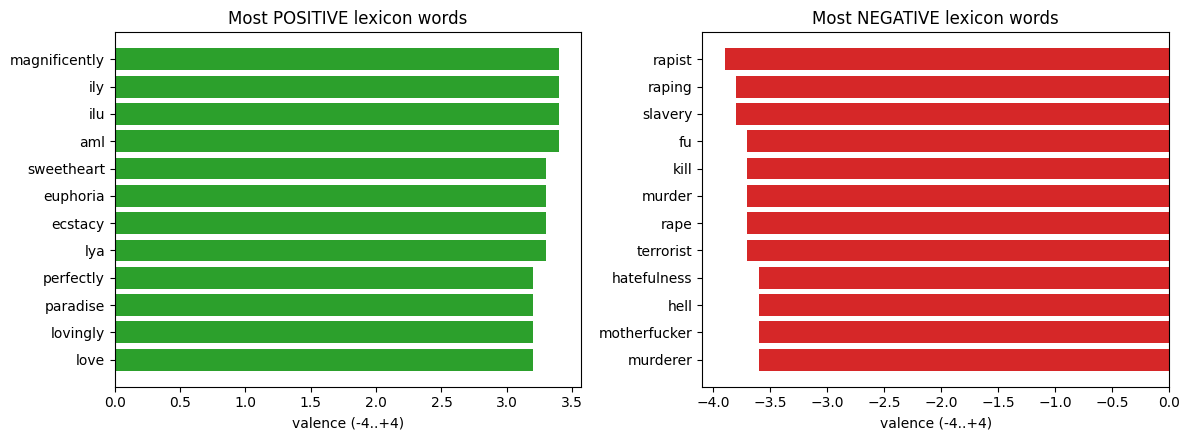

In [14]:
lex = sia.lexicon                       # dict: word -> valence in [-4, +4]
lex_items = sorted(lex.items(), key=lambda kv: kv[1])
neg_lex = lex_items[:12]
pos_lex = lex_items[-12:][::-1]
print(f"VADER lexicon size: {len(lex):,} words (hand-assigned valences, domain-independent)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, items, title, color in [
    (axes[0], pos_lex, "Most POSITIVE lexicon words", "#2ca02c"),
    (axes[1], neg_lex, "Most NEGATIVE lexicon words", "#d62728")]:
    words = [w for w, _ in items][::-1]; vals = [v for _, v in items][::-1]
    ax.barh(words, vals, color=color); ax.set_title(title); ax.set_xlabel("valence (-4..+4)")
plt.tight_layout(); plt.show()

**Interpretation.** VADER is interpretable *by construction*: its score is the rule-adjusted sum of these fixed
valences. But the strongest words are **generic English** (`great`, `love`, `nice` / `terrible`, `horrible`,
`awful`) and the weights were **hand-assigned, not learned from movie reviews**. That is VADER's blessing
(total transparency) and its curse (no domain knowledge) — a point §C makes quantitative.

### B2. Token-level SHAP for one review (analogue of the waterfall) ✅

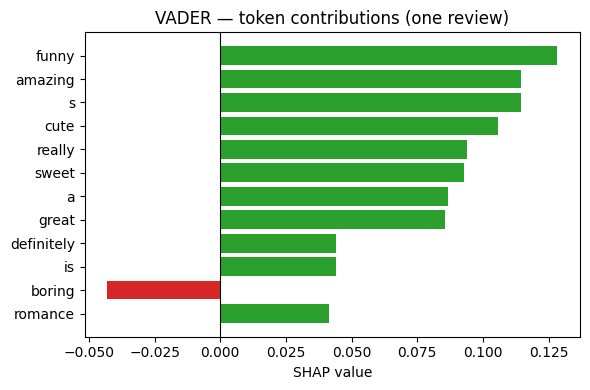

In [15]:
# Prediction functions on RAW review text; each model applies ITS OWN preprocessing internally.
def f_lr(texts):
    return lr.predict_proba([clean_full(t) for t in texts])[:, 1]      # P(positive)
def f_vader(texts):
    return np.array([sia.polarity_scores(clean_minimal(t))["compound"] for t in texts])

text_masker = shap.maskers.Text(r"\W+")
expl_lr_txt = shap.Explainer(f_lr,   text_masker)
expl_v_txt  = shap.Explainer(f_vader, text_masker)

def token_bar(values, tokens, title, k=12, ax=None):
    toks = [t.strip().strip(",.!?;:\"'()[]") for t in tokens]   # clean labels for display
    keep = [i for i in range(len(toks)) if toks[i]]
    o = sorted(keep, key=lambda i: abs(values[i]))[-k:]
    if ax is None: fig, ax = plt.subplots(figsize=(6, 4))
    ax.barh([toks[i] for i in o], [values[i] for i in o],
            color=["#d62728" if values[i] < 0 else "#2ca02c" for i in o])
    ax.axvline(0, color="k", lw=.8); ax.set_title(title); ax.set_xlabel("SHAP value")

# explain one clearly positive review
demo_txt = df_test[(df_test.sentiment_label == 1) & (df_test.vader_pred == 1)
                   & (df_test.text.str.split().apply(len).between(25, 50))] \
                   .sort_values("vader_c", ascending=False).iloc[0]["text"]
sv = expl_v_txt([clean_minimal(demo_txt)], max_evals=MAX_EVALS_TEXT, batch_size=50)
token_bar(sv.values[0], sv.data[0], "VADER — token contributions (one review)"); plt.tight_layout(); plt.show()
try:
    shap.plots.text(sv[0])     # rich inline highlighting (renders in Jupyter)
except Exception as e:
    print("(shap.plots.text needs a JS-capable viewer)", e)

**Interpretation.** Token-level SHAP shows VADER reacting to exactly the surface words contained in its
lexicon, modulated by punctuation/capitalisation. It has a genuine sense of *intensity and structure* but, as
the next section shows, no sense of which words matter **for movie reviews specifically**.

### B3. VADER's rules in action (negation, intensity, capitalisation)

In [16]:
for s in ["good", "not good", "GOOD!!!", "not that good", "really bad", "not bad at all"]:
    print(f"  {s:>15s} -> compound = {sia.polarity_scores(s)['compound']:+.3f}")

             good -> compound = +0.440
         not good -> compound = -0.341
          GOOD!!! -> compound = +0.583
    not that good -> compound = -0.341
       really bad -> compound = -0.585
   not bad at all -> compound = +0.431


**Interpretation.** VADER's rules *do* handle simple, local negation and intensity (`good` → positive,
`not good` → negative, `GOOD!!!` → stronger). This is its main edge over a plain lexicon — but the rules are
**shallow** and break on longer-range or rhetorical negation, which is the failure we isolate next.

## C. Cross-model comparison — *on what basis does each model classify?*

We compare the models on a **common footing** in two complementary ways:

1. **Global** — put the two models' "word dictionaries" side by side: VADER's lexicon valence vs. the LR model's
   learned coefficient, on the words they share.
2. **Local** — run the **same token-level SHAP** (same masker, same review) on both models, for one case where
   they **agree** and one where they **disagree**.

### C1. Global: VADER lexicon valence vs. learned LR coefficient

shared words: 1265 | Pearson=0.372 | Spearman=0.381 | sign agreement=63.3%


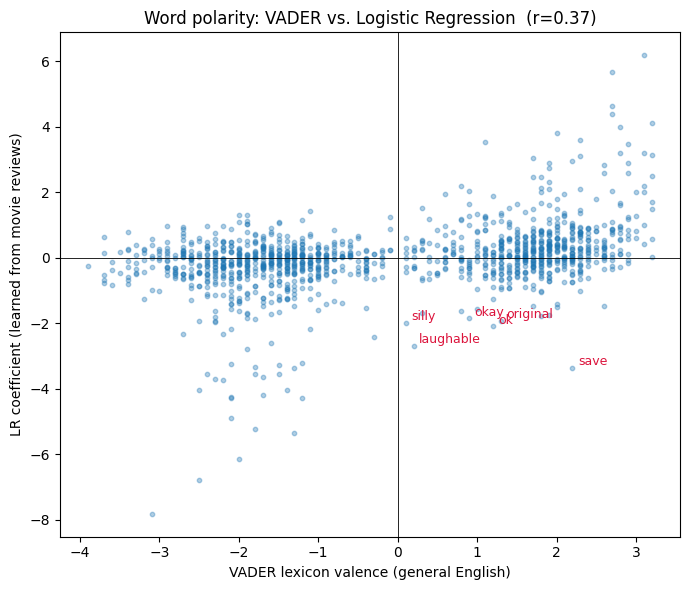

Words VADER reads as positive but the model learned are NEGATIVE in reviews:
        save: VADER +2.2  vs  LR -3.38
   laughable: VADER +0.2  vs  LR -2.71
          ok: VADER +1.2  vs  LR -2.10
       silly: VADER +0.1  vs  LR -2.00
    original: VADER +1.3  vs  LR -1.93
        okay: VADER +0.9  vs  LR -1.85


In [17]:
coef_uni = {w: c for w, c in zip(vocab, clf.coef_[0]) if " " not in w}   # unigrams only
shared = [w for w in lex if w in coef_uni]
vx = np.array([lex[w]      for w in shared])
cy = np.array([coef_uni[w] for w in shared])

pear = pearsonr(vx, cy)[0]; spear = spearmanr(vx, cy)[0]
sign_agree = float(np.mean(np.sign(vx) == np.sign(cy)))
print(f"shared words: {len(shared)} | Pearson={pear:.3f} | Spearman={spear:.3f} | sign agreement={sign_agree:.1%}")

plt.figure(figsize=(7, 6))
plt.scatter(vx, cy, s=10, alpha=0.35)
plt.axhline(0, color="k", lw=.6); plt.axvline(0, color="k", lw=.6)
plt.xlabel("VADER lexicon valence (general English)")
plt.ylabel("LR coefficient (learned from movie reviews)")
plt.title(f"Word polarity: VADER vs. Logistic Regression  (r={pear:.2f})")
# annotate the most informative disagreements
dis = sorted([(w, lex[w], coef_uni[w]) for w in shared
              if np.sign(lex[w]) != np.sign(coef_uni[w]) and abs(coef_uni[w]) > 1.8],
             key=lambda t: -abs(t[2]))[:6]
for w, xv, yv in dis:
    plt.annotate(w, (xv, yv), fontsize=9, color="crimson",
                 xytext=(4, 2), textcoords="offset points")
plt.tight_layout(); plt.show()
print("Words VADER reads as positive but the model learned are NEGATIVE in reviews:")
for w, xv, yv in dis:
    print(f"  {w:>10s}: VADER {xv:+.1f}  vs  LR {yv:+.2f}")

**Interpretation.** Agreement is only **moderate** (Pearson ≈ 0.37, signs agree ≈ 63% of the time). The
*systematic* disagreements are the story: words like `save`, `ok`, `laughable` are mildly **positive** in
VADER's general lexicon but strongly **negative** in the learned model — because in movie reviews they live in
phrases like *"save your money"*, *"just ok"*, *"laughably bad"*. **The LR model has learned the domain's real
sentiment vocabulary; VADER applies generic English sentiment.** This mismatch is the root cause of the
accuracy gap, and the next example shows it firing on a single review.

### C2. Local — a case where the models AGREE (both correct, positive)

TRUE = positive | VADER compound = 0.977 (pos) | LR P(pos) = 0.995 (pos)

But perhaps you have to have grown up in the 80's to truly appreciate this movie. If you love the early 80's this is definitely a must see. Also, one of the best soundtracks ever! 



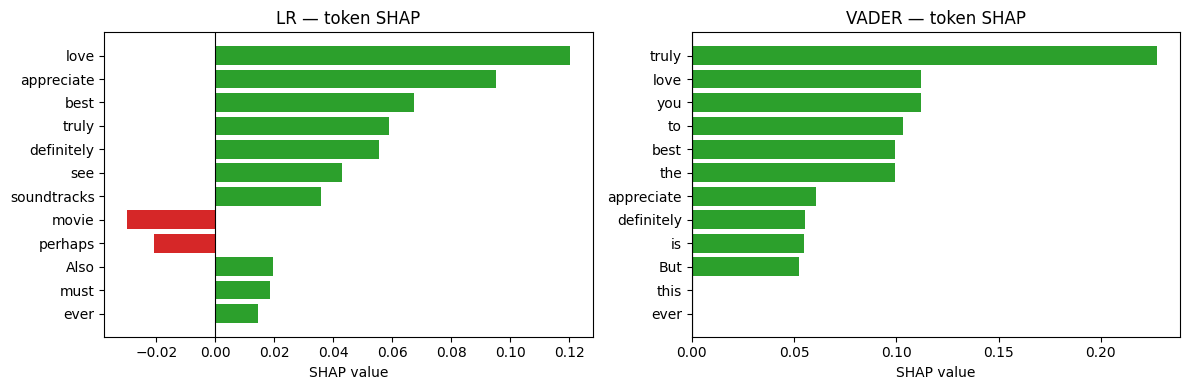

In [18]:
agree = df_test[(df_test.sentiment_label == 1) & (df_test.vader_pred == 1) & (df_test.lr_pred == 1)
                & (df_test.text.str.split().apply(len).between(25, 55))] \
                .sort_values("lr_p", ascending=False).iloc[0]
print("TRUE = positive | VADER compound =", round(agree.vader_c, 3),
      "(pos) | LR P(pos) =", round(agree.lr_p, 3), "(pos)\n")
print(clean_minimal(agree.text), "\n")

sv_lr = expl_lr_txt([clean_minimal(agree.text)], max_evals=MAX_EVALS_TEXT, batch_size=50)
sv_v  = expl_v_txt([clean_minimal(agree.text)],  max_evals=MAX_EVALS_TEXT, batch_size=50)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
token_bar(sv_lr.values[0], sv_lr.data[0], "LR — token SHAP", ax=ax[0])
token_bar(sv_v.values[0],  sv_v.data[0],  "VADER — token SHAP", ax=ax[1])
plt.tight_layout(); plt.show()

**Interpretation.** When a review is unambiguous, the two models **agree for the same reasons** — both lock onto
the explicit positive words (`best`, `love`, `must see`). On easy cases the choice of model barely matters.

### C3. Local — a case where the models DISAGREE (VADER wrong, LR right) — the key finding

TRUE = negative | VADER compound = 0.969 (-> predicts POSITIVE, WRONG) | LR P(pos) = 0.029 (-> predicts NEGATIVE, correct)

they (dueringer, dorfer) are good stand-up comedians, young, not ugly, have money, the girls love them, the audience is appreciating everything there doing and then they made this film ... no story at all, some jokes were old in the fifties, the acting is awful. save your money for something useful, like a gift for your girlfriend. 



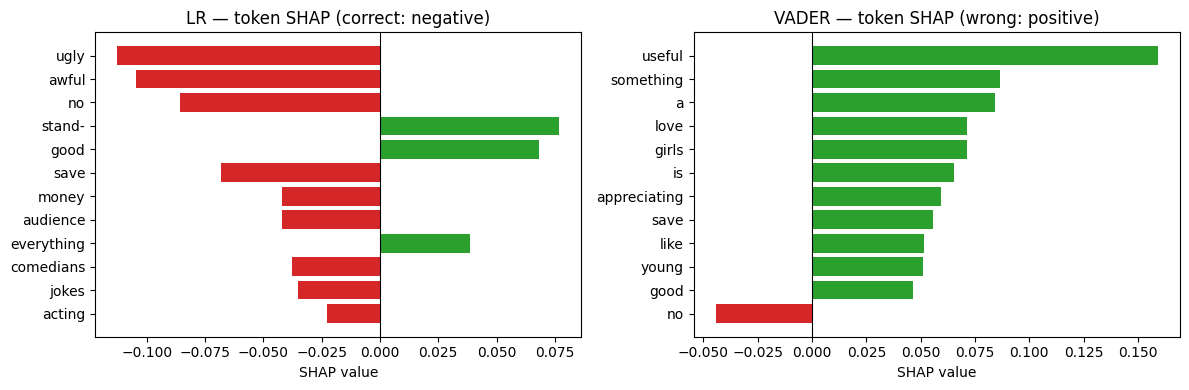

In [19]:
# True NEGATIVE that VADER calls POSITIVE (a false positive) but LR correctly calls NEGATIVE.
# To make the link to C1 concrete, we pick the most confident such case that also uses one of the
# domain-mismatch words from C1 ("save": VADER reads it as positive, the model learned it is negative).
_cand = df_test[(df_test.sentiment_label == 0) & (df_test.vader_pred == 1) & (df_test.lr_pred == 0)
                & (df_test.lr_p < 0.05)
                & (df_test.text.str.contains(r"\bsave\b", case=False, regex=True))
                & (df_test.text.str.split().apply(len).between(30, 65))]
disag = _cand.sort_values("vader_c", ascending=False).iloc[0]
print("TRUE = negative | VADER compound =", round(disag.vader_c, 3),
      "(-> predicts POSITIVE, WRONG) | LR P(pos) =", round(disag.lr_p, 3), "(-> predicts NEGATIVE, correct)\n")
print(clean_minimal(disag.text), "\n")

sv_lr = expl_lr_txt([clean_minimal(disag.text)], max_evals=MAX_EVALS_TEXT, batch_size=50)
sv_v  = expl_v_txt([clean_minimal(disag.text)],  max_evals=MAX_EVALS_TEXT, batch_size=50)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
token_bar(sv_lr.values[0], sv_lr.data[0], "LR — token SHAP (correct: negative)", ax=ax[0])
token_bar(sv_v.values[0],  sv_v.data[0],  "VADER — token SHAP (wrong: positive)", ax=ax[1])
plt.tight_layout(); plt.show()

**Interpretation — this is the crux.** This negative review is a textbook VADER failure. The review first
praises the *comedians* ("good stand-up comedians", "the girls **love** them", audience "appreciating"…) and
ends with the sarcastic aside *"**save** your money for something **useful**, like a **gift** for your
girlfriend."* VADER scores it **≈ +0.97 → POSITIVE (badly wrong)** because it keys on those isolated positive
words (`love`, `good`, `appreciating`, `useful`, `gift`) and has **no way to tell that they do not describe the
film's quality**. The LR model scores **P(positive) ≈ 0.03 → NEGATIVE (correct)** because it keys on the actual
verdict — `no` (no story), `awful`, and `save`/`money` (*save your money*). Note `save` is one of the §C1
domain-mismatch words in action: VADER's general lexicon reads it as positive, but the model learned it signals
a negative review. This combination — **VADER's positive bias from surface words it cannot attribute to the
right target, plus domain-blindness** — is exactly what produced its ~5,790 false positives and the ~19-point
accuracy gap from §1.

### C4. Summary — interpretability comparison

| Dimension | **VADER** | **TF-IDF + Logistic Regression** |
|---|---|---|
| Decision basis | Sum of **fixed** dictionary valences + heuristic rules | Sum of **learned** n-gram weights × TF-IDF |
| Source of "importance" | The lexicon (hand-built) | Coefficients (estimated from 25k reviews) |
| Domain adaptation | **None** — generic English | **Yes** — learned movie-review polarity (`save`, `ok`, `laughable`…) |
| Negation handling | Shallow local rule — **fails** on rhetorical/long-range negation | Via explicit **bigrams** (`not good`, `waste time`) |
| Context / interactions | Rule-based intensity & punctuation | **No interactions** (linear) except bigram features |
| Capitalisation / "!" | Uses them (operates on `text_raw`) | Ignored (lowercased, punctuation stripped) |
| Transparency type | **Intrinsic** (white-box by design) | **Post-hoc** but exact (SHAP = coef × value) |
| Typical error | **False positives** (positive bias) | Roughly **balanced** errors |
| Test accuracy | ≈ 69.9% | ≈ 88.6% |
| Best for | Zero-training baseline, full transparency | Production: accuracy **and** per-prediction explanations |

## D. Counterfactual explanation — *"what would need to change?"* (Bonus)

We take a **borderline** review and greedily remove the words that most reduce `P(positive)` until the
prediction flips. The smallest such set is a counterfactual: *"the review is positive **because of** these
words."*

In [20]:
def counterfactual(text, max_remove=6):
    base_p = float(lr.predict_proba([clean_full(text)])[0, 1])
    tokens = clean_full(text).split()
    removed, cur, cur_p = [], list(tokens), base_p
    for _ in range(max_remove):
        if (cur_p < 0.5) != (base_p < 0.5):
            break
        best, best_p = None, cur_p
        for w in set(cur):
            p = float(lr.predict_proba([" ".join(t for t in cur if t != w)])[0, 1])
            if (base_p >= 0.5 and p < best_p) or (base_p < 0.5 and p > best_p):
                best, best_p = w, p
        if best is None:
            break
        cur = [t for t in cur if t != best]; removed.append(best); cur_p = best_p
    return base_p, cur_p, removed

cf_row = df_test[(df_test.sentiment_label == 1) & (df_test.lr_p.between(0.6, 0.8))
                 & (df_test.text.str.split().apply(len).between(20, 50))].sort_values("lr_p").iloc[0]
bp, cp, rem = counterfactual(cf_row.text)
print(cf_row.text[:280], "...\n")
print(f"P(positive): {bp:.3f}  ->  {cp:.3f}   after removing: {rem}")
print("Prediction flipped:", (cp < 0.5) != (bp < 0.5))

Some TV programs continue into embarrassment (my beloved 'X-Files' comes to mind.) I've been a fan of Dennis Farina since 'Crime Story,' another late, lamented show. 'Buddy Faro' never had a chance. The series had a good premise and great actors. It's really, really a shame. ...

P(positive): 0.604  ->  0.483   after removing: ['great']
Prediction flipped: True


**Interpretation.** The minimal counterfactual is striking — removing the single word **`great`** flips this
review from *positive* to *negative*. This quantifies exactly how the decision hangs together and gives
analysts an actionable, per-prediction statement (*"classified positive primarily because of `great`"*), useful
for spotting fragile classifications before acting on them.

## E. LIME — an independent cross-check

SHAP and LIME are **different methods**: SHAP attributes the prediction with game-theoretic Shapley values
(consistent, additive); LIME fits a **local linear surrogate** on randomly perturbed versions of the review. If
both point to the same words, we can trust those words are the model's *real* drivers, not an artefact of one
technique.

In [21]:
def lr_proba_2col(texts):
    return lr.predict_proba([clean_full(t) for t in texts])

lime_explainer = LimeTextExplainer(class_names=["negative", "positive"])
lime_exp = lime_explainer.explain_instance(disag.text, lr_proba_2col,
                                           num_features=8, num_samples=300)
print("LIME top words for the §C3 disagreement review (negative weight pushes 'negative'):")
for w, wt in lime_exp.as_list():
    print(f"  {w:>14s}: {wt:+.3f}")

LIME top words for the §C3 disagreement review (negative weight pushes 'negative'):
           awful: -0.098
            save: -0.073
           money: -0.072
              no: -0.050
            love: +0.036
            ugly: -0.031
           stand: +0.030
            gift: +0.018


**Interpretation.** LIME independently flags **`awful`**, **`money`**, **`save`** and **`no`** as the dominant
negative drivers — the same evidence SHAP found in §C3, and ignoring the positive words about the comedians.
Two methodologically distinct explainers converging on the same words is strong confirmation that this is
genuinely *why* the LR model labels the review negative.

## Conclusions

**On what basis do the models classify?**
- **Logistic Regression** sums *learned* TF-IDF weights. SHAP shows it relies on a transparent weighted
  checklist of sentiment words (`great/best/excellent…` vs `bad/worst/waste/not even…`), captures negation only
  through explicit **bigrams**, and — being linear — has **no feature interactions** (the dependence plot is a
  perfect line). Every prediction comes with an exact, auditable per-word breakdown.
- **VADER** sums *fixed*, hand-built lexicon valences plus shallow rules. It is white-box by design but
  **domain-blind** and only weakly negation-aware.

**Why the 19-point accuracy gap (interpretability-driven explanation).** The lexicon-vs-coefficient comparison
(§C1) shows VADER and the trained model disagree on the sign of many domain words (`save`, `ok`, `laughable`…),
and the disagreement case (§C3) shows the consequence in one review: VADER over-weights isolated positive words
and fumbles negation, producing the **positive bias / ~5,790 false positives** seen in its confusion matrix.
The LR model avoids this because it *learned* the corpus's true word polarities and uses bigrams for local
context.

**Which model would we deploy?** **TF-IDF + Logistic Regression** — it is both more accurate *and* fully
explainable per prediction (SHAP/LIME/counterfactuals), so an analyst can justify or contest any automated
label. VADER remains valuable as a **zero-training, fully transparent baseline**.

**On choosing an interpretability method (the "what's best to compare across models" question).** No single
plot fits both models. We used `LinearExplainer` for the linear model (exact and cheap), the **lexicon itself**
as VADER's global importance, and **model-agnostic token-level SHAP** as the common footing for local,
side-by-side comparison — with **LIME** as an independent check.

**Limitations & next steps.** (1) `LinearExplainer` with an empty-document baseline credits only present tokens;
a different baseline would redistribute attributions. (2) Token-level SHAP is computed on a few reviews because
it is expensive (each review needs hundreds of model evaluations); scale up `MAX_EVALS_TEXT` / the sample for a
corpus-level token comparison. (3) For the transformer models in the project, neither tool transfers directly —
use a SHAP `PartitionExplainer` with the model tokenizer (or attention-based attributions) and compare against
the linear model on the same reviews.